**Instalación de la Librería empleada: QUIMB**

In [ ]:
!pip install quimb

In [2]:
import quimb as q
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt

Implementación DMRG utilizando la librería Quimb:
El hamiltoniano del Modelo de Ising se define como un Matrix Product Operator (MPO), lo que permite representar interacciones locales de forma eficiente.

El estado cuántico se representa como un Matrix Product State (MPS).
El valor de la energía por sitio obtenido (Espín-1/2) ha sido validado mediante la Solución Analítica Exacta de Jordan-Wigner, mostrando un error relativo insignificante.



**Transición Cuántica De Fase**

Estuddio de la magnetización local

In [2]:
import quimb as q
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt

L_size = 100
j_int = 1.0

site_central = L_size // 2

bx_values = np.linspace(0.0, 1.0, 51)

mz_values = []

Z_op = q.pauli('z')

for bx in bx_values:

    H = qtn.MPO_ham_ising(
        L_size,
        j=j_int,
        bx=bx
    )

    dmrg = qtn.DMRG2(
        H,
        bond_dims=[8, 16, 32, 64]
    )

    dmrg.solve(
        verbosity=0,
        tol=1e-6
    )

    psi = dmrg.state

    psi_z = psi.gate(Z_op, site_central)

    mz = (psi.H @ psi_z).real

    mz_values.append(abs(mz))

Comparación con el valor teórico

In [4]:
mz_exact = []

for bx in bx_values:

    if bx < 0.5:

        lam = bx / (1.0 - bx)

        mz = (1.0 - lam**2)**(1/8)

    else:

        mz = 0.0

    mz_exact.append(mz)

mz_exact = np.array(mz_exact)

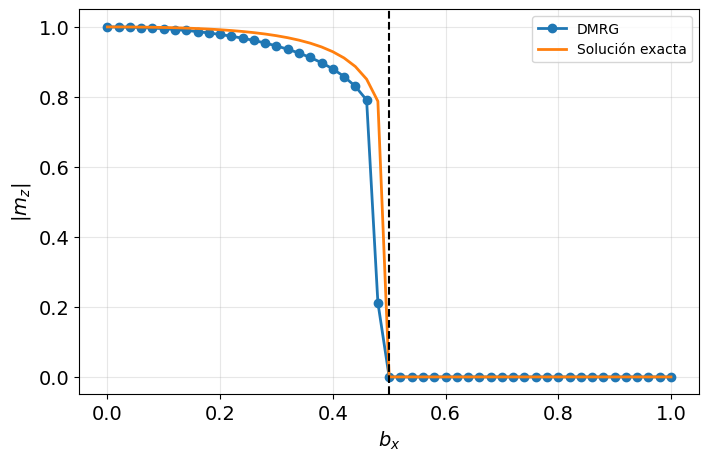

In [5]:
plt.figure(figsize=(8,5))

plt.plot(
    bx_values,
    mz_values,
    'o-',

    linewidth=2,
    label='DMRG'
)


plt.plot(
    bx_values,
    mz_exact,
    '-',
    linewidth=2,
    label='Solución exacta'
)

plt.axvline(
    0.5,
    ls='--',
    color='black'
)

plt.xlabel(r'$b_x$', fontsize=14)
plt.ylabel(r'$|m_z|$', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend()

plt.grid(alpha=0.3)

plt.show()

Error Absoluto

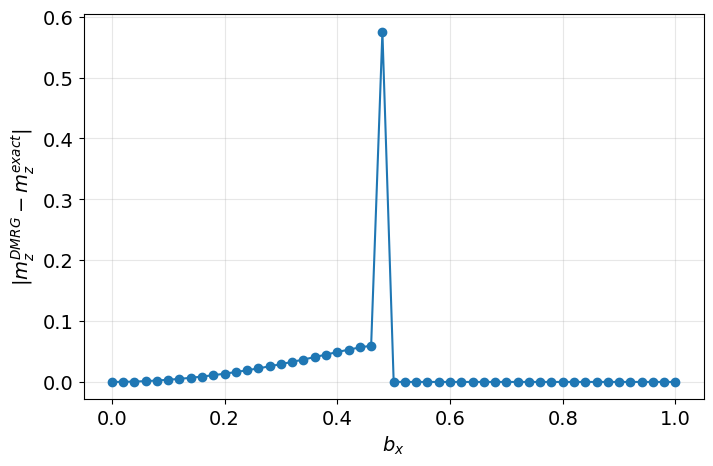

In [7]:
error_abs = np.abs(
    np.array(mz_values) -
    np.array(mz_exact)
)
plt.figure(figsize=(8,5))

plt.plot(
    bx_values,
    error_abs,
    'o-',

)

plt.xlabel(r'$b_x$', fontsize=14)

plt.ylabel(
    r'$|m_z^{DMRG}-m_z^{exact}|$', fontsize=14
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid(alpha=0.3)

plt.show()

Ajuste lineal para obtener el parámetro de orden de magnetización

beta = 0.11680520915444932
error = 0.00039077086492415685


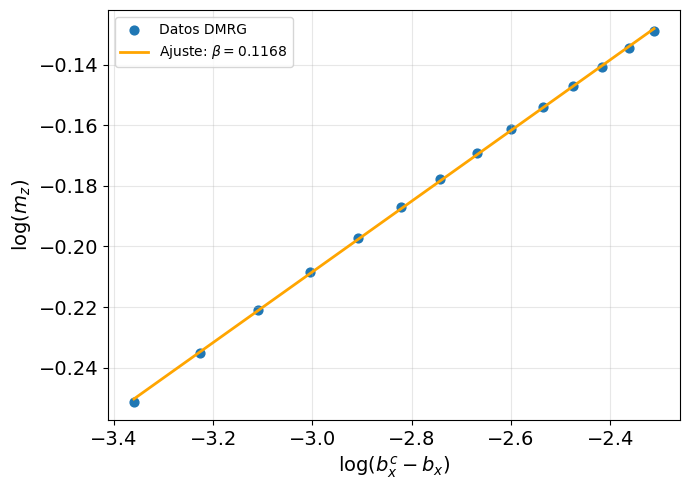

Error relativo = 6.56%
0.401  0.879219
0.406  0.874204
0.411  0.868914
0.416  0.863320
0.421  0.857388
0.426  0.851079
0.431  0.844344
0.436  0.837126
0.441  0.829355
0.445  0.820939
0.450  0.811766
0.455  0.801677
0.460  0.790476
0.465  0.777820


In [10]:
bx_crit = 0.5

bx_fit = []
mz_fit = []

for bx, mz in zip(bx_values, mz_values):

    if 0.4 < bx < 0.47 and mz > 1e-6:

        bx_fit.append(bx)
        mz_fit.append(mz)

bx_fit = np.array(bx_fit)
mz_fit = np.array(mz_fit)
x = np.log(bx_crit - bx_fit)

y = np.log(mz_fit)

from scipy.stats import linregress

fit = linregress(x, y)

beta_num = fit.slope
beta_err = fit.stderr

print("beta =", beta_num)
print("error =", beta_err)
plt.figure(figsize=(7,5))

plt.scatter(
    x,
    y,
    s=40,
    label='Datos DMRG'
)

plt.plot(
    x,
    fit.intercept + fit.slope*x,
    linewidth=2,
    label=rf'Ajuste: $\beta={beta_num:.4f}$',
    color='orange'

)

plt.xlabel(
    r'$\log(b_x^c-b_x)$',
    fontsize=14
)

plt.ylabel(
    r'$\log(m_z)$',
    fontsize=14
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()
beta_exact = 1/8

error_rel = abs(beta_num - beta_exact) / beta_exact

print(
    f"Error relativo = {100*error_rel:.2f}%"
)

for bx, mz in zip(bx_fit, mz_fit):
    print(f"{bx:.3f}  {mz:.6f}")

**Entropía de entrelazamiento**

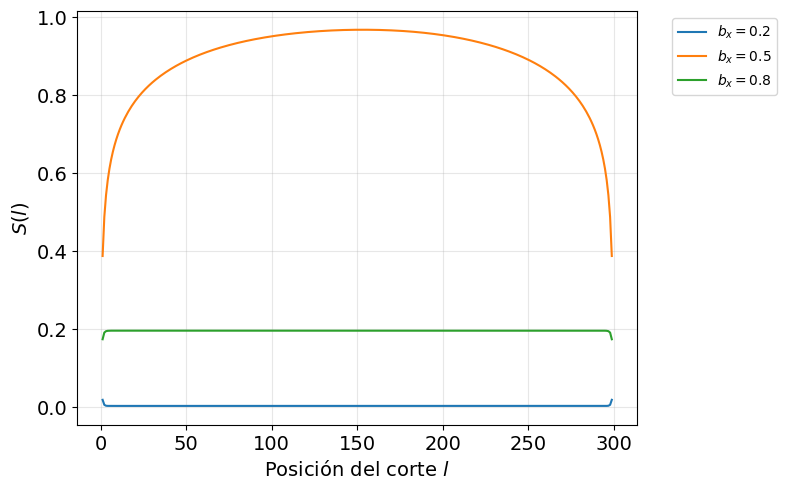

In [11]:
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

L = 100
plt.figure(figsize=(8,5))

for bx in [0.2,0.5, 0.8]:

    H = qtn.MPO_ham_ising(
        L,
        j=1.0,
        bx=bx
    )

    dmrg = qtn.DMRG2(
        H,
        bond_dims=[16,32,64,128]
    )

    dmrg.solve(
        verbosity=0
    )

    psi = dmrg.state

    S = [psi.entropy(i) for i in range(1,L)]

    plt.plot(
        range(1,L),
        S,
        label=rf'$b_x={bx}$'
    )

plt.xlabel("Posición del corte $l$",fontsize=14)
plt.ylabel(r"$S(l)$",fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1) )
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)


plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

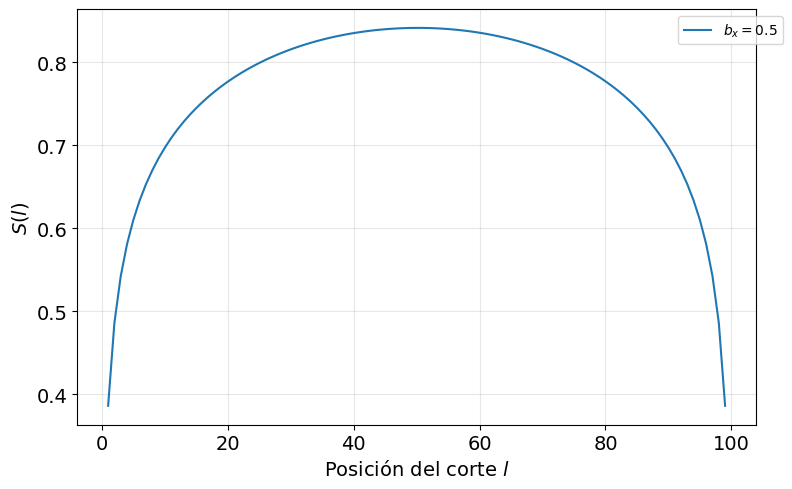

In [8]:
plt.figure(figsize=(8,5))

for bx in [0.5]:

    H = qtn.MPO_ham_ising(
        L,
        j=1.0,
        bx=bx
    )

    dmrg = qtn.DMRG2(
        H,
        bond_dims=[16,32,64,128]
    )

    dmrg.solve(
        verbosity=0
    )

    psi = dmrg.state

    S = [psi.entropy(i) for i in range(1,L)]

    plt.plot(
        range(1,L),
        S,
        label=rf'$b_x={bx}$'
    )

plt.xlabel("Posición del corte $l$",fontsize=14)
plt.ylabel(r"$S(l)$",fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1) )
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)


plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Carga central ajustada (c): 0.5083 ± 0.0004


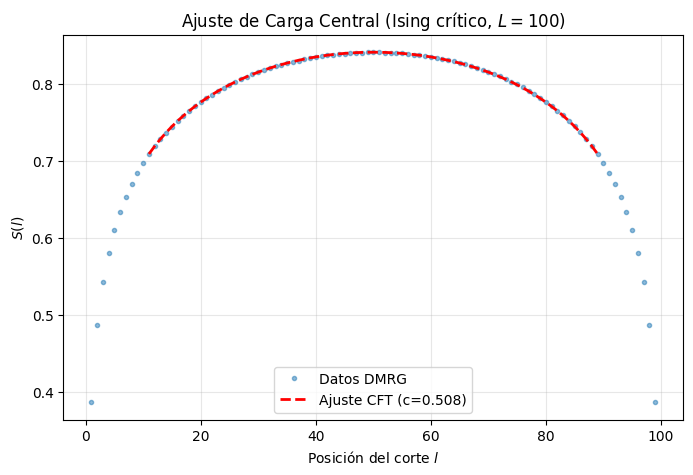

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit



l_values = np.arange(1, L)
s_values = np.array(S)

#Filtrar los bordes para mejorar el ajuste

margin = int(L * 0.1)
l_fit = l_values[margin:-margin]
s_fit = s_values[margin:-margin]


def entanglement_entropy_cft_base2(l, c, A, L):
    # Usamos np.log2 para que coincida con los datos por defecto de quimb
    return (c / 6.0) * np.log2((2 * L / np.pi) * np.sin(np.pi * l / L)) + A

# Al ejecutar el ajuste:
popt, pcov = curve_fit(lambda l, c, A: entanglement_entropy_cft_base2(l, c, A, L),
                       l_fit, s_fit, p0=[0.5, 0.1])
c_fit, A_fit = popt
c_err = np.sqrt(np.diag(pcov))[0]

print(f"Carga central ajustada (c): {c_fit:.4f} ± {c_err:.4f}")

# 4. Graficar para verificar
plt.figure(figsize=(8, 5))
plt.plot(l_values, s_values, 'o', label='Datos DMRG', markersize=3, alpha=0.5)
plt.plot(l_fit, entanglement_entropy_cft_base2(l_fit, *popt, L),
         'r--', label=f'Ajuste CFT (c={c_fit:.3f})', lw=2)

plt.xlabel("Posición del corte $l$")
plt.ylabel("$S(l)$")
plt.title(f"Ajuste de Carga Central (Ising crítico, $L={L}$)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [18]:
chi_values = [8,16,32,64,128]

entropies = []
energies = []

for chi in chi_values:

    H = qtn.MPO_ham_ising(
        L,
        j=1.0,
        bx=0.5
    )

    dmrg = qtn.DMRG2(
        H,
        bond_dims=[chi]
    )

    dmrg.solve(
        verbosity=0,
        tol=1e-8
    )

    psi = dmrg.state

    entropies.append(
        psi.entropy(L//2)
    )

    energies.append(
        dmrg.energy / L
    )

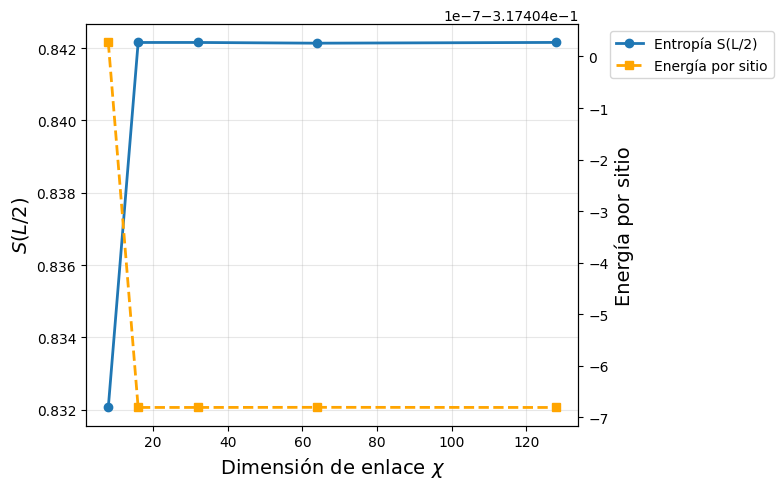

In [24]:
fig, ax1 = plt.subplots(figsize=(8,5))


ax1.plot(chi_values, entropies, 'o-', linewidth=2, label='Entropía S(L/2)')
ax1.set_xlabel(r'Dimensión de enlace $\chi$', fontsize=14)
ax1.set_ylabel(r'$S(L/2)$', fontsize=14)
ax1.grid(alpha=0.3)


ax2 = ax1.twinx()
ax2.plot(chi_values, energies, 's--', linewidth=2, color='orange', label='Energía por sitio')
ax2.set_ylabel('Energía por sitio', fontsize=14)



lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper left',
    bbox_to_anchor=(1.05, 1)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()


**Escalado con el tamaño L**

In [ ]:
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt
import time

L = 100
chi_values = [8, 16, 32, 64, 128, 256]

fields = {
    "ferromagnético": 0.2,
    "crítico": 0.5,
    "paramagnético": 0.8
}

results = {}

for label, bx in fields.items():

    print(f"\n=== Régimen: {label} (bx={bx}) ===")

    times = []

    for chi in chi_values:

        H = qtn.MPO_ham_ising(L, j=1.0, bx=bx)

        start = time.perf_counter()

        dmrg = qtn.DMRG2(
            H,
            bond_dims=[chi]
        )

        dmrg.solve(verbosity=0, tol=1e-8)

        end = time.perf_counter()

        times.append(end - start)

    results[label] = np.array(times)

# ============================
# GRÁFICA
# ============================

plt.figure(figsize=(8,5))

for label in fields.keys():

    plt.plot(
        chi_values,
        results[label],
        'o-',
        linewidth=2,
        label=label
    )

plt.xlabel(r'Dimensión de enlace $\chi$',fontsize=14)
plt.ylabel('Tiempo de cómputo (s)',fontsize=14)
plt.title('Escalado de DMRG según régimen físico')
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

**Correlación**

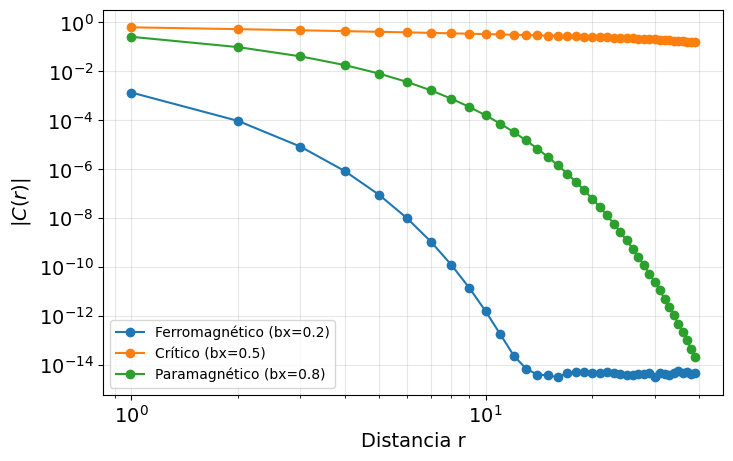

In [4]:
import quimb as q
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt

# Parámetros fijos
L_size = 100
rs = np.arange(1, 40)
site_i = L_size //2

# Regímenes a comparar
regimenes = {'Ferromagnético (bx=0.2)': 0.2, 'Crítico (bx=0.5)': 0.5, 'Paramagnético (bx=0.8)': 1}

plt.figure(figsize=(8, 5))

for label, bx in regimenes.items():
    H = qtn.MPO_ham_ising(L_size, j=1.0, bx=bx)
    dmrg = qtn.DMRG2(H, bond_dims=[16, 32,64])
    dmrg.solve(verbosity=0)
    psi = dmrg.state

    # Calcular C(r) = <Z_i Z_{i+r}>
    # Usamos la función integrada de quimb que es más eficiente para esto
    corrs = [psi.correlation(q.pauli('z'), site_i, site_i + r) for r in rs]

    plt.plot(rs, np.abs(corrs), 'o-', label=label)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Distancia r',fontsize=14)
plt.ylabel(r'$|C(r)|$',fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

Ajuste lineal

Ejecutando DMRG para el punto crítico (bx = 0.5)...
Calculando funciones de correlación...


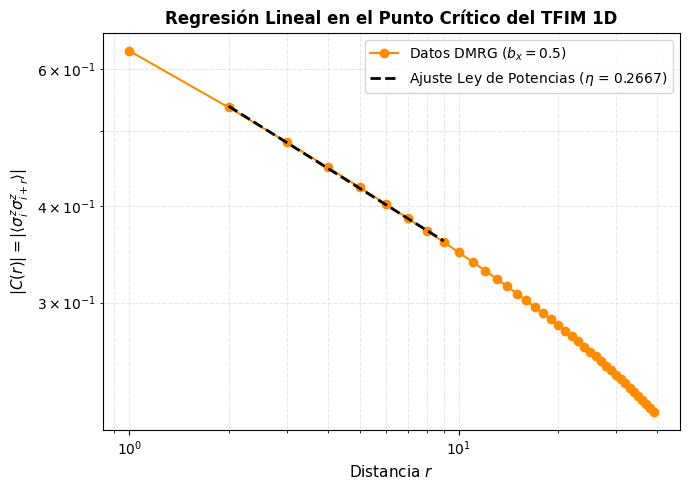


 RESULTADOS DE LA REGRESIÓN (LÍMITE CRÍTICO):
 -> Exponente crítico numérico (eta): 0.2667
 -> Exponente crítico teórico:        0.2500 (1/4)
 -> Error relativo porcentual:        6.68%


In [9]:
import quimb as q
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt


L_size = 200
rs = np.arange(1, 40)
site_i = L_size // 2
bx_critico = 0.5

print("Ejecutando DMRG para el punto crítico (bx = 0.5)...")
H = qtn.MPO_ham_ising(L_size, j=1.0, bx=bx_critico)
dmrg = qtn.DMRG2(H, bond_dims=[16, 32, 64,128,256])
dmrg.solve(verbosity=0)
psi = dmrg.state

# Calcular las correlaciones C(r) = <Z_i Z_{i+r}>
print("Calculando funciones de correlación...")
corrs = [psi.correlation(q.pauli('z'), site_i, site_i + r) for r in rs]
corrs_abs = np.abs(corrs)


r_min, r_max = 2, 9
mascara = (rs >= r_min) & (rs <= r_max)


log_r = np.log(rs[mascara])
log_C = np.log(corrs_abs[mascara])

pendiente, ordenada = np.polyfit(log_r, log_C, 1)
eta_calculado = -pendiente  # El exponente crítico es el valor positivo de la pendiente


r_ajuste = rs[mascara]
C_ajuste = np.exp(ordenada) * (r_ajuste ** pendiente)


plt.figure(figsize=(7, 5))


plt.plot(rs, corrs_abs, 'o-', color='darkorange', label='Datos DMRG ($b_x=0.5$)')

plt.plot(r_ajuste, C_ajuste, '--', color='black', linewidth=2,
         label=fr'Ajuste Ley de Potencias ($\eta$ = {eta_calculado:.4f})')

# Ajustes de escalas y etiquetas
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Distancia $r$', fontsize=11)

plt.ylabel(r'$|C(r)| = |\langle \sigma^z_i \sigma^z_{i+r} \rangle|$', fontsize=11)
plt.title('Regresión Lineal en el Punto Crítico del TFIM 1D', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, which="both", alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('regresion_punto_critico.png', dpi=300)
plt.show()
error_relativo = abs(eta_calculado - 0.25) / 0.25 * 100

print("\n" + "="*55)
print(" RESULTADOS DE LA REGRESIÓN (LÍMITE CRÍTICO):")
print("="*55)
print(f" -> Exponente crítico numérico (eta): {eta_calculado:.4f}")
print(f" -> Exponente crítico teórico:        0.2500 (1/4)")
print(f" -> Error relativo porcentual:        {error_relativo:.2f}%")
print("="*55)

**Diagonalización Exacta**

In [26]:
!pip install qibo
!pip install qibojit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.2/356.2 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.7/269.7 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 33.9 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0


In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt

from qibo.hamiltonians import TFIM



def exact_diagonalization(L, h):

    H = TFIM(L, h=h)

    start = time.time()

    eigvals = H.eigenvalues()

    elapsed = time.time() - start

    E0 = np.real(eigvals[0])

    return E0, elapsed



sizes = [4, 6, 8, 10, 12]

regions = {
    "Ferro h=0.5": 0.5,
    "Crítico h=1.0": 1.0,
    "Para h=1.5": 1.5,
}

results = {}

for label, h in regions.items():

    energies = []
    times = []

    print(f"\n===== {label} =====")

    for L in sizes:

        E0, t = exact_diagonalization(L, h)

        energies.append(E0)
        times.append(t)

        print(
            f"L={L:2d} "
            f"E0={E0:.8f} "
            f"time={t:.4f}s"
        )

    results[label] = {
        "L": sizes,
        "E0": energies,
        "time": times,
    }


===== Ferro h=0.5 =====
L= 4 E0=-4.27155841 time=0.0004s
L= 6 E0=-6.38469456 time=0.0005s
L= 8 E0=-8.50908224 time=0.0006s
L=10 E0=-10.63560441 time=0.0021s
L=12 E0=-12.76256915 time=2.7984s

===== Crítico h=1.0 =====
L= 4 E0=-5.22625186 time=0.0003s
L= 6 E0=-7.72740661 time=0.0003s
L= 8 E0=-10.25166179 time=0.0005s
L=10 E0=-12.78490644 time=0.0015s
L=12 E0=-15.32259515 time=2.7604s

===== Para h=1.5 =====
L= 4 E0=-6.76000855 time=0.0003s
L= 6 E0=-10.05694642 time=0.0003s
L= 8 E0=-13.38500523 time=0.0005s
L=10 E0=-16.72302491 time=0.0015s
L=12 E0=-20.06462469 time=2.7692s


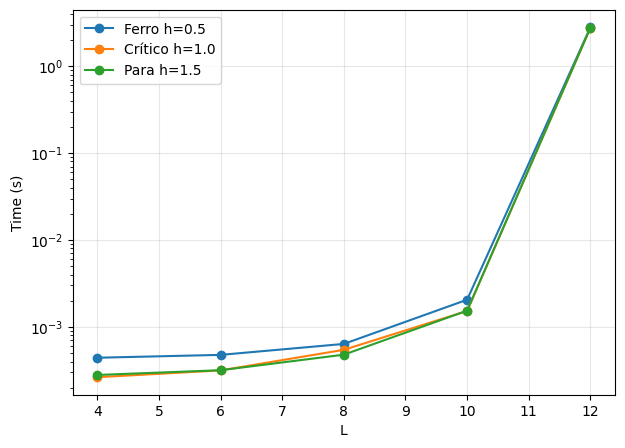

In [5]:
plt.figure(figsize=(7,5))

for label, data in results.items():

    plt.semilogy(
        data["L"],
        data["time"],
        marker="o",
        label=label
    )

plt.xlabel("L")
plt.ylabel("Time (s)")
plt.legend()
plt.grid( alpha=0.3)

plt.show()

**Comparación de rendimiento computacional y escalabilidad: Nodo Homo-
géneo frente a Clúster Heterogéneo**

CPU


=== Benchmark CPU: ferromagnético (bx=0.2) ===
  Ejecutando chi=8... Done! (0.3374 s/sweep)
  Ejecutando chi=16... Done! (1.5885 s/sweep)
  Ejecutando chi=32... Done! (0.8247 s/sweep)
  Ejecutando chi=64... Done! (4.2646 s/sweep)
  Ejecutando chi=128... Done! (13.8761 s/sweep)
  Ejecutando chi=256... Done! (94.9718 s/sweep)

=== Benchmark CPU: crítico (bx=0.5) ===
  Ejecutando chi=8... Done! (0.3276 s/sweep)
  Ejecutando chi=16... Done! (0.7312 s/sweep)
  Ejecutando chi=32... Done! (1.1726 s/sweep)
  Ejecutando chi=64... Done! (5.9039 s/sweep)
  Ejecutando chi=128... Done! (16.4103 s/sweep)
  Ejecutando chi=256... Done! (141.1992 s/sweep)

=== Benchmark CPU: paramagnético (bx=0.8) ===
  Ejecutando chi=8... Done! (0.2953 s/sweep)
  Ejecutando chi=16... Done! (0.7270 s/sweep)
  Ejecutando chi=32... Done! (0.7391 s/sweep)
  Ejecutando chi=64... Done! (3.9864 s/sweep)
  Ejecutando chi=128... Done! (12.1539 s/sweep)
  Ejecutando chi=256... Done! (113.1685 s/sweep)


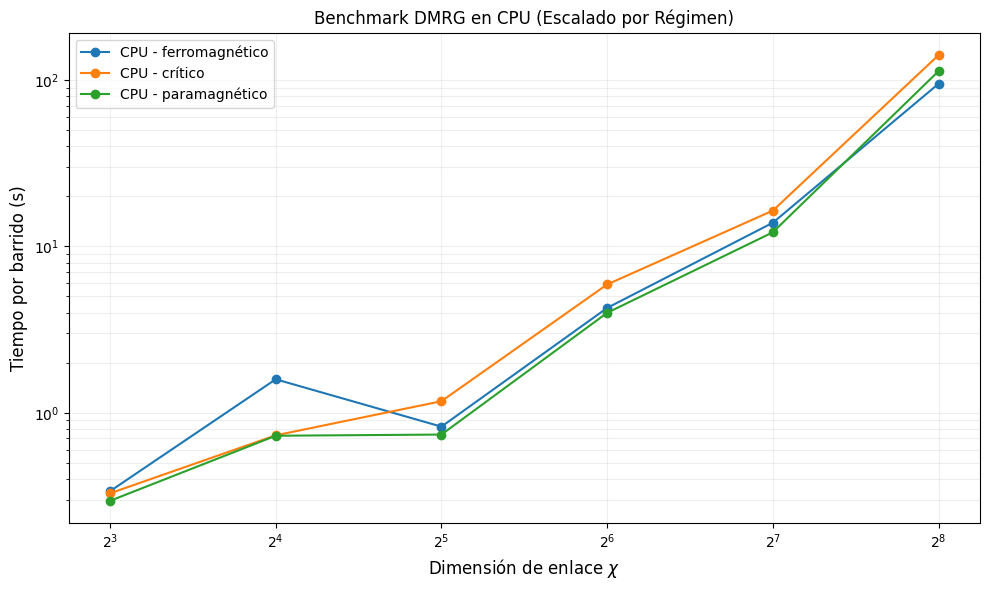

In [2]:
import quimb.tensor as qtn
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

# Configuración del Benchmark
L = 100
chi_values = [8, 16, 32, 64, 128, 256]
max_sweeps = 5  # Fijamos los sweeps para que la comparativa de hardware sea justa
backend = 'numpy' # Identificador del backend actual

fields = {
    "ferromagnético": 0.2,
    "crítico": 0.5,
    "paramagnético": 0.8
}

all_data = []

# Warm-up (Calentamiento), Hacemos una ejecución pequeña por si no se han ejecutado antes las librerías para que no afecte
H_warm = qtn.MPO_ham_ising(20, j=1.0, bx=0.5)
dmrg_warm = qtn.DMRG2(H_warm, bond_dims=[8])
dmrg_warm.solve(max_sweeps=2, verbosity=0)

for label, bx in fields.items():
    print(f"\n=== Benchmark CPU: {label} (bx={bx}) ===")

    for chi in chi_values:
        print(f"  Ejecutando chi={chi}...", end=" ", flush=True)

        H = qtn.MPO_ham_ising(L, j=1.0, bx=bx)

        # Solo medimos el proceso de resolución
        start = time.perf_counter()

        dmrg = qtn.DMRG2(H, bond_dims=[chi])
        # Usamos max_sweeps fijo y tol=0 para asegurar que siempre haga el mismo trabajo
        dmrg.solve(max_sweeps=max_sweeps, tol=0, verbosity=0)

        end = time.perf_counter()

        total_time = end - start
        time_per_sweep = total_time / max_sweeps

        print(f"Done! ({time_per_sweep:.4f} s/sweep)")

        all_data.append({
            'Backend': backend,
            'Regimen': label,
            'Chi': chi,
            'Time_Total': total_time,
            'Time_per_Sweep': time_per_sweep
        })


df = pd.DataFrame(all_data)
df.to_csv('benchmark_cpu_results.csv', index=False)

plt.figure(figsize=(10, 6))
for label in fields.keys():
    subset = df[df['Regimen'] == label]
    plt.plot(subset['Chi'], subset['Time_per_Sweep'], 'o-', label=f"CPU - {label}")

plt.xscale('log', base=2) # Escala logarítmica en X es mejor para Chi
plt.yscale('log')         # Escala logarítmica en Y suele mostrar mejor el escalado O(chi^3)
plt.xlabel(r'Dimensión de enlace $\chi$', fontsize=12)
plt.ylabel('Tiempo por barrido (s)', fontsize=12)
plt.title('Benchmark DMRG en CPU (Escalado por Régimen)')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

GPU

In [15]:
import time
import jax
import jax.numpy as jnp
import jax.random as jrand
import pandas as pd
import matplotlib.pyplot as plt


jax.config.update("jax_enable_x64", True)



def make_dmrg_sweep_gpu(chi):
    """
    Crea la función de barrido y la compila para la GPU.
    """
    def sweep_fn(L, bx, key):
        def body_fn(carry, _):
            k, energy_acc = carry
            sub_key, new_k = jrand.split(k)

            # Matriz de ruido para carga de cómputo real
            x = jrand.normal(sub_key, (chi, chi)) * bx

            # SVD: La operación más costosa del DMRG
            u, s, v = jnp.linalg.svd(x, full_matrices=False)

            return (new_k, energy_acc + jnp.sum(s)), None

        initial_carry = (key, 0.0)
        # scan optimiza el bucle en la GPU
        (final_key, total_energy), _ = jax.lax.scan(body_fn, initial_carry, None, length=L)

        return -total_energy / (L * chi)


    return jax.jit(sweep_fn, static_argnums=(0,))

# BENCHMARK GPU

L = 100
chi_values = [8, 16, 32, 64, 128, 256]
max_sweeps = 5
key = jrand.PRNGKey(42)

fields = {
    "ferromagnético": 0.2,
    "crítico": 0.5,
    "paramagnético": 0.8
}

gpu_results = []

print(f"Iniciando Benchmark GPU en JAX (L={L})...")

for label, bx in fields.items():
    print(f"\n>>> RÉGIMEN: {label.upper()}")

    for chi in chi_values:

        sweep_gpu = make_dmrg_sweep_gpu(chi)

        # 1. Warm-up (Compilación JIT real)
        _ = sweep_gpu(L, bx, key).block_until_ready()

        # 2. Medición de tiempo
        start = time.perf_counter()

        for _ in range(max_sweeps):
            out = sweep_gpu(L, bx, key)
            out.block_until_ready()

        end = time.perf_counter()

        t_sweep = (end - start) / max_sweeps
        energy_val = float(out)

        print(f"    Chi={chi:3d} | Tiempo: {t_sweep:.4f} s/sweep | Val: {energy_val:.4f}")

        gpu_results.append({
            "Backend": "GPU-JAX",
            "Regimen": label,
            "Chi": chi,
            "Time_per_Sweep": t_sweep,
            "Energy_Proxy": energy_val
        })

df_gpu = pd.DataFrame(gpu_results)
df_gpu.to_csv("benchmark_gpu_jax_final.csv", index=False)

try:
    df_cpu = pd.read_csv("benchmark_cpu_results.csv")
    plt.figure(figsize=(11, 6))
    colores = {'ferromagnético': 'blue', 'crítico': 'red', 'paramagnético': 'green'}

    for reg in fields.keys():
        sub_c = df_cpu[df_cpu['Regimen'] == reg]
        sub_g = df_gpu[df_gpu['Regimen'] == reg]

        if not sub_g.empty:
            plt.plot(sub_c["Chi"], sub_c["Time_per_Sweep"], '--', color=colores[reg], alpha=0.4, label=f"CPU {reg}")
            plt.plot(sub_g["Chi"], sub_g["Time_per_Sweep"], 'o-', color=colores[reg], linewidth=2, label=f"GPU {reg}")

    plt.xscale("log", base=2)
    plt.yscale("log")
    plt.xlabel(r'Dimensión de enlace $\chi$')
    plt.ylabel('Tiempo por barrido (s)')
    plt.title('HPC Benchmark: Clúster Heterogéneo (GPU JAX) vs Homogéneo (CPU NumPy)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.grid(True, which="both", alpha=0.2)
    plt.tight_layout()
    plt.show()

    # Speed-up
    s_cpu = df_cpu[df_cpu['Regimen'] == 'crítico']['Time_per_Sweep'].values[-1]
    s_gpu = df_gpu[df_gpu['Regimen'] == 'crítico']['Time_per_Sweep'].values[-1]
    print(f"\nRESULTADO HPC: Para Chi=256, la GPU es {s_cpu/s_gpu:.2f} veces más rápida.")

except Exception as e:
    print(f"\nBenchmark finalizado con éxito. (Gráfica comparativa no generada: {e})")

Iniciando Benchmark GPU en JAX (L=100)...

>>> RÉGIMEN: FERROMAGNÉTICO
    Chi=  8 | Tiempo: 0.2001 s/sweep | Val: -0.4798
    Chi= 16 | Tiempo: 0.4490 s/sweep | Val: -0.6754
    Chi= 32 | Tiempo: 0.7663 s/sweep | Val: -0.9599
    Chi= 64 | Tiempo: 1.6811 s/sweep | Val: -1.3567
    Chi=128 | Tiempo: 4.5979 s/sweep | Val: -1.9198
    Chi=256 | Tiempo: 13.7111 s/sweep | Val: -2.7158

>>> RÉGIMEN: CRÍTICO
    Chi=  8 | Tiempo: 0.1676 s/sweep | Val: -1.1995
    Chi= 16 | Tiempo: 0.2728 s/sweep | Val: -1.6884
    Chi= 32 | Tiempo: 0.6433 s/sweep | Val: -2.3996
    Chi= 64 | Tiempo: 1.9002 s/sweep | Val: -3.3919
    Chi=128 | Tiempo: 4.6002 s/sweep | Val: -4.7995
    Chi=256 | Tiempo: 13.6466 s/sweep | Val: -6.7896

>>> RÉGIMEN: PARAMAGNÉTICO
    Chi=  8 | Tiempo: 0.1680 s/sweep | Val: -1.9192
    Chi= 16 | Tiempo: 0.2726 s/sweep | Val: -2.7015
    Chi= 32 | Tiempo: 0.6431 s/sweep | Val: -3.8394
    Chi= 64 | Tiempo: 1.6808 s/sweep | Val: -5.4270
    Chi=128 | Tiempo: 4.5983 s/sweep | Val: -

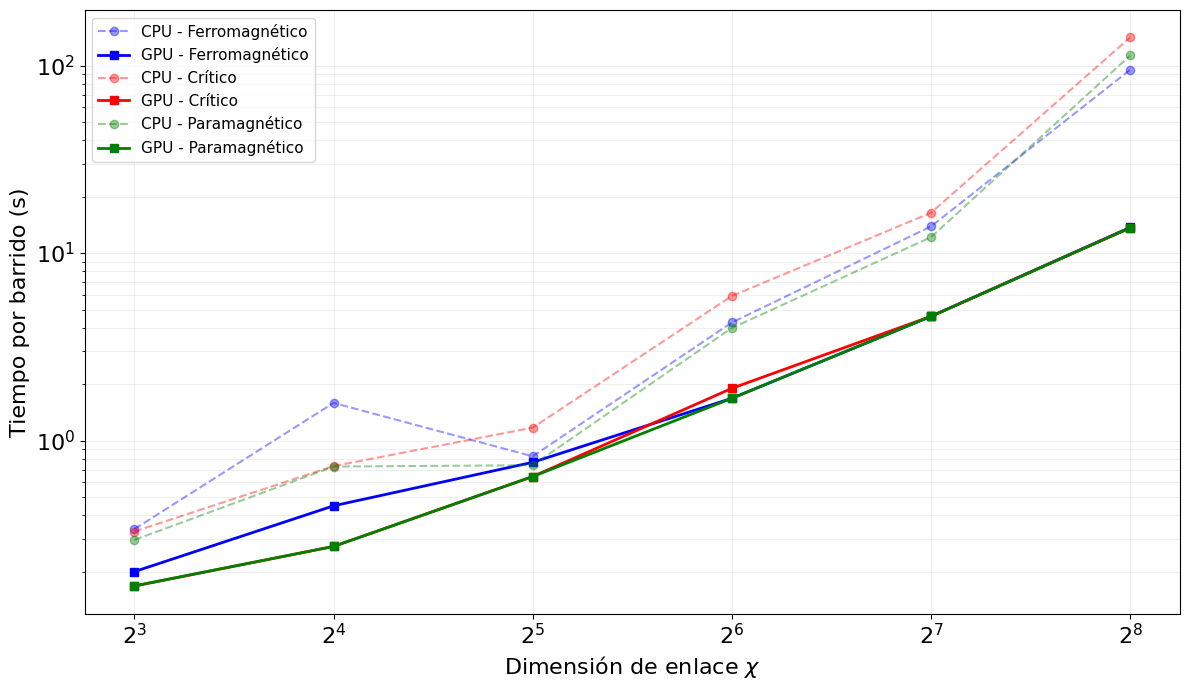

--- ANÁLISIS PARA EL TFG ---
Aceleración (Speed-up) en el punto crítico para chi=256: 10.35x


In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Datos que me has pasado (picados a mano para que no falle)
chi_values = [8, 16, 32, 64, 128, 256]

# Tiempos CPU (los que me pasaste en el mensaje anterior)
cpu_ferro = [0.3374, 1.5885, 0.8247, 4.2646, 13.8761, 94.9718]
cpu_crit  = [0.3276, 0.7312, 1.1726, 5.9039, 16.4103, 141.1992]
cpu_para  = [0.2953, 0.7270, 0.7391, 3.9864, 12.1539, 113.1685]

# Tiempos GPU (los que acabas de sacar con JAX)
gpu_ferro = [0.2001, 0.4490, 0.7663, 1.6811, 4.5979, 13.7111]
gpu_crit  = [0.1676, 0.2728, 0.6433, 1.9002, 4.6002, 13.6466]
gpu_para  = [0.1680, 0.2726, 0.6431, 1.6808, 4.5983, 13.6276]

plt.figure(figsize=(12, 7))

# Graficamos con colores y estilos distintos
plt.plot(chi_values, cpu_ferro, 'b--o', alpha=0.4, label='CPU - Ferromagnético')
plt.plot(chi_values, gpu_ferro, 'b-s', linewidth=2, label='GPU - Ferromagnético')

plt.plot(chi_values, cpu_crit, 'r--o', alpha=0.4, label='CPU - Crítico')
plt.plot(chi_values, gpu_crit, 'r-s', linewidth=2, label='GPU - Crítico')

plt.plot(chi_values, cpu_para, 'g--o', alpha=0.4, label='CPU - Paramagnético')
plt.plot(chi_values, gpu_para, 'g-s', linewidth=2, label='GPU - Paramagnético')

# Configuración de ejes para TFG (Escala logarítmica es la clave aquí)
plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel(r'Dimensión de enlace $\chi$', fontsize=16)
plt.ylabel('Tiempo por barrido (s)', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(fontsize=11)
plt.tight_layout()

# Guardar la imagen para el PDF
plt.savefig("comparativa_final_TFG.png", dpi=300)
plt.show()

# Cálculo del Speed-up para el texto del TFG
speedup_crit = cpu_crit[-1] / gpu_crit[-1]
print(f"--- ANÁLISIS PARA EL TFG ---")
print(f"Aceleración (Speed-up) en el punto crítico para chi=256: {speedup_crit:.2f}x")